# Logistic curve fitting

The goal of this project is to evaluate fitting procedures to fit logistic curves with incomplete data. The problem is that when there only is data to the left of the inflection point, logistic fits tend to get extremly senitive to measurement errors.

In [4]:
# Initialize
library(tidyverse)

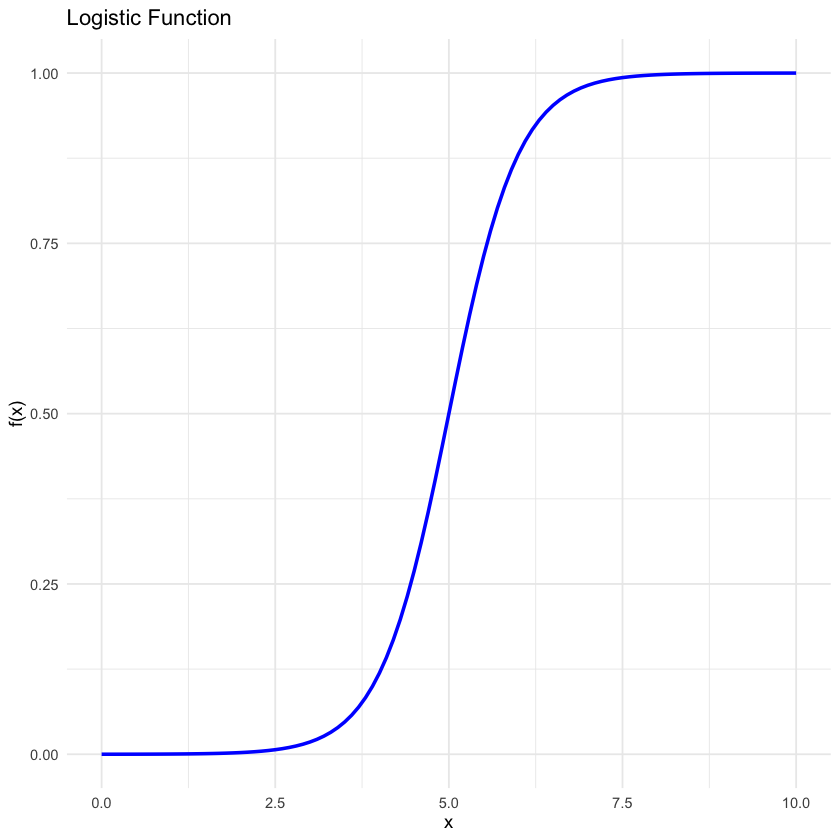

In [5]:
# Parameters for the logistic function
niveau <- 1
rate <- 2
inflection <- 5

x <- seq(0, 10, by = 0.1)
# Logistic function
logistic_function <- function(x, niveau, rate, inflection) {
  niveau / (1 + exp(-rate * (x - inflection)))
}

# Calculate the logistic function values
y <- logistic_function(x, niveau, rate, inflection)

# Create a data frame for plotting
tbl <- tibble(
    x = x,
    y = y
)

# Plot the logistic function
ggplot(tbl, aes(x = x, y = y)) +
  geom_line(color = "blue", size = 1) +
  labs(title = "Logistic Function",
       x = "x",
       y = "f(x)") +
  theme_minimal()

parameter,true,median,q05,q95,n_eff,Rhat
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
niveau,1,1.010990,0.9506954,1.084030,852.3326,1.005205
inflection,5,5.008798,4.9410109,5.085078,834.7089,1.005315
rate,2,1.986042,1.8962997,2.076918,893.4509,1.004577


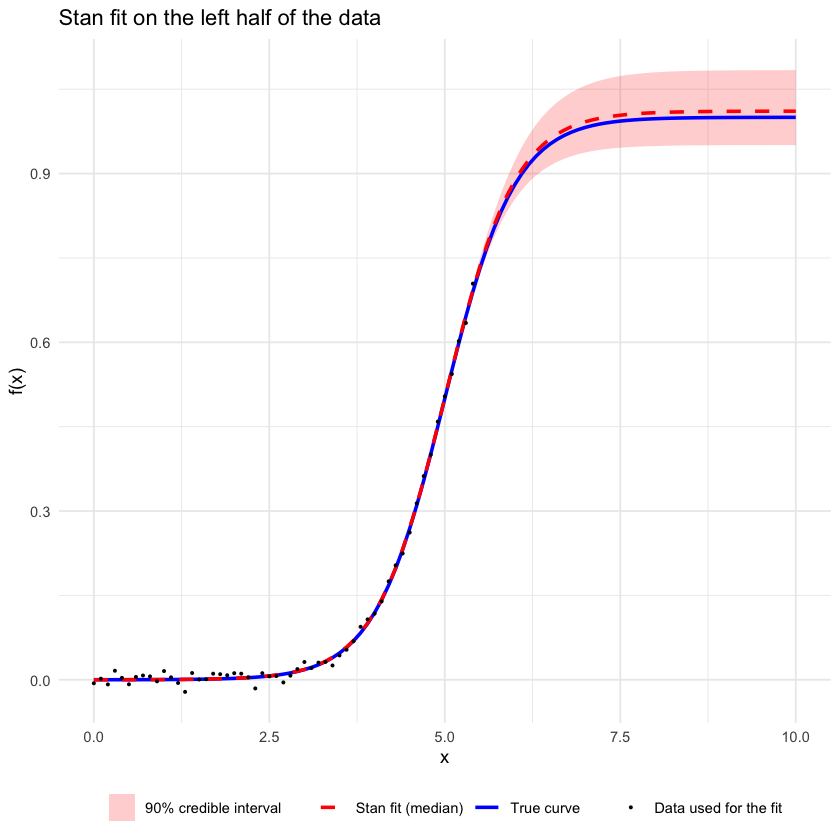

In [10]:
library(rstan)

set.seed(1)

# Add an error term and keep only the left half of the data for fitting
tbl <- tbl |>
  mutate(
    err = rnorm(nrow(tbl), mean = 0, sd = 0.01),
    y_obs = y + err
  )

tbl_half <- tbl |>
  slice_head(n = as.integer(nrow(tbl) * 0.55))

# Fit the logistic curve with Stan (model defined in logistic.stan)
fit <- stan(
    file = "logistic.stan",
    data = list(
        N = nrow(tbl_half),
        x = tbl_half$x,
        y = tbl_half$y_obs,
        N_pred = nrow(tbl),
        x_pred = tbl$x
    ),
    chains = 4,
    cores = 4,
    seed = 1,
    refresh = 0
)

# Compare the posterior of the parameters with the true values
pars <- c("niveau", "inflection", "rate")
summary(fit, pars = pars, probs = c(0.05, 0.5, 0.95))$summary |>
  as_tibble(rownames = "parameter") |>
  mutate(true = c(niveau, inflection, rate)) |>
  select(parameter, true, median = `50%`, q05 = `5%`, q95 = `95%`, n_eff, Rhat)

# Plot the true curve, the data used for the fit and the fitted curve with its 90% credible interval
pred <- summary(fit, pars = "mu_pred", probs = c(0.05, 0.5, 0.95))$summary

tbl |>
  mutate(y_fit = pred[, "50%"], y_lower = pred[, "5%"], y_upper = pred[, "95%"]) |>
  ggplot(aes(x = x)) +
  geom_ribbon(aes(ymin = y_lower, ymax = y_upper, fill = "90% credible interval"), alpha = 0.2) +
  geom_line(aes(y = y, color = "True curve", linetype = "True curve"), linewidth = 1) +
  geom_line(aes(y = y_fit, color = "Stan fit (median)", linetype = "Stan fit (median)"), linewidth = 1) +
  geom_point(data = tbl_half, aes(y = y_obs, shape = "Data used for the fit"), size = 0.8) +
  scale_color_manual(values = c("True curve" = "blue", "Stan fit (median)" = "red")) +
  scale_linetype_manual(values = c("True curve" = "solid", "Stan fit (median)" = "dashed")) +
  scale_fill_manual(values = c("90% credible interval" = "red")) +
  scale_shape_manual(values = c("Data used for the fit" = 16)) +
  labs(title = "Stan fit on the left half of the data",
       x = "x",
       y = "f(x)",
       color = NULL, linetype = NULL, fill = NULL, shape = NULL) +
  theme_minimal() +
  theme(legend.position = "bottom")